In [1]:
import pandas as pd
import time
from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori as mlx_apriori
from mlxtend.frequent_patterns import fpgrowth as mlx_fpgrowth
from mlxtend.frequent_patterns import association_rules
 
from src.association.apriori import custom_apriori, generate_custom_rules
from src.association.fpgrowth import custom_fpgrowth

# Load and clean data
def load_products(file_path):
    with open(file_path, 'r', encoding='utf-8') as f:
        return [
            [item.strip() for item in line.strip().split(',') if item.strip()]
            for line in f
            if line.strip()
        ]

def mlxtend_rules_to_df(lib_rules_df: pd.DataFrame) -> pd.DataFrame:
    """Normalise mlxtend rules to the same column layout as custom rules."""
    df = lib_rules_df.copy()
    df["antecedents"] = df["antecedents"].apply(lambda x: ", ".join(sorted(x)))
    df["consequents"] = df["consequents"].apply(lambda x: ", ".join(sorted(x)))
    return (
        df[["antecedents", "consequents", "support", "confidence", "lift"]]
        .rename(columns={
            "antecedents": "Antecedents",
            "consequents": "Consequents",
            "support":     "Support",
            "confidence":  "Confidence",
            "lift":        "Lift",
        })
        .sort_values("Lift", ascending=False)
        .reset_index(drop=True)
    )

def run_mlxtend_pipeline(df_ohe, algorithm, min_support, min_confidence, min_lift):
    """Run mlxtend frequent-itemset + association-rules pipeline, return (rules_df, elapsed)."""
    start = time.perf_counter()
    itemsets = algorithm(df_ohe, min_support=min_support, use_colnames=True)
    rules = association_rules(itemsets, metric="confidence", min_threshold=min_confidence)
    rules = rules[rules["lift"] >= min_lift]
    elapsed = time.perf_counter() - start
    return mlxtend_rules_to_df(rules), len(itemsets), elapsed
 
 
def run_custom_pipeline(fn_itemsets, transactions, min_support, min_confidence, min_lift):
    """Run a custom itemset + rules pipeline, return (rules_df, elapsed)."""
    start = time.perf_counter()
    itemsets = fn_itemsets(transactions, min_support)
    rules = generate_custom_rules(itemsets, min_confidence, min_lift)
    elapsed = time.perf_counter() - start
    return rules, len(itemsets), elapsed
 
 
#  Pretty-print helpers
_COL_W = {"Antecedents": 36, "Consequents": 28, "Support": 10, "Confidence": 12, "Lift": 8}
_COLS  = list(_COL_W)
 
def _header() -> str:
    return "  ".join(c.ljust(_COL_W[c]) for c in _COLS)
 
def _separator() -> str:
    return "  ".join("-" * _COL_W[c] for c in _COLS)
 
def _row(r) -> str:
    parts = [
        str(r["Antecedents"])[: _COL_W["Antecedents"]].ljust(_COL_W["Antecedents"]),
        str(r["Consequents"])[: _COL_W["Consequents"]].ljust(_COL_W["Consequents"]),
        f"{r['Support']:.4f}".ljust(_COL_W["Support"]),
        f"{r['Confidence']:.4f}".ljust(_COL_W["Confidence"]),
        f"{r['Lift']:.4f}".ljust(_COL_W["Lift"]),
    ]
    return "  ".join(parts)
 
def print_comparison_block(title: str, custom_result, library_result, top_n: int = 5):
    """
    Print a side-by-side comparison block for one algorithm pair.
    """
    c_rules, c_items, c_time = custom_result
    l_rules, l_items, l_time = library_result
 
    width = len(_header())
    double = "═" * width
 
    print(f"\n{'═' * 6}  {title}  {'═' * (width - len(title) - 9)}")
    print()
 
    # Summary row
    print(f"  {'':30s}  {'Custom':>12}  {'Library (mlxtend)':>18}")
    print(f"  {'Frequent itemsets found':<30}  {c_items:>12}  {l_items:>18}")
    print(f"  {'Association rules found':<30}  {len(c_rules):>12}  {len(l_rules):>18}")
    print(f"  {'Execution time (sec)':<30}  {c_time:>12.4f}  {l_time:>18.4f}")
 
    # Top-N rules
    for label, df in (("Custom", c_rules), ("Library (mlxtend)", l_rules)):
        print(f"\n  Top-{top_n} rules by Lift  [{label}]:")
        print("  " + _header())
        print("  " + _separator())
        if df.empty:
            print("  (no rules found)")
        else:
            for _, row in df.head(top_n).iterrows():
                print("  " + _row(row))
 
    print()

In [2]:
MIN_SUPPORT    = 0.05
MIN_CONFIDENCE = 0.1
MIN_LIFT       = 1.0
TOP_N          = 5

# Load data
transactions = load_products("data/groceries.txt")
print(f"Total transactions loaded: {len(transactions)}")
print(f"Parameters: Support={MIN_SUPPORT}, Confidence={MIN_CONFIDENCE}, Lift={MIN_LIFT}\n")

# OHE for mlxtend
te = TransactionEncoder()
df_ohe = pd.DataFrame(
    te.fit(transactions).transform(transactions),
    columns=te.columns_,
)

# Apriori
custom_apr = run_custom_pipeline(
    custom_apriori, transactions, MIN_SUPPORT, MIN_CONFIDENCE, MIN_LIFT
)
lib_apr = run_mlxtend_pipeline(
    df_ohe, mlx_apriori, MIN_SUPPORT, MIN_CONFIDENCE, MIN_LIFT
)
print_comparison_block("APRIORI", custom_apr, lib_apr, top_n=TOP_N)

# FP-Growth
custom_fp = run_custom_pipeline(
    custom_fpgrowth, transactions, MIN_SUPPORT, MIN_CONFIDENCE, MIN_LIFT
)
lib_fp = run_mlxtend_pipeline(
    df_ohe, mlx_fpgrowth, MIN_SUPPORT, MIN_CONFIDENCE, MIN_LIFT
)
print_comparison_block("FP-GROWTH", custom_fp, lib_fp, top_n=TOP_N)

Total transactions loaded: 9835
Parameters: Support=0.05, Confidence=0.1, Lift=1.0


══════  APRIORI  ══════════════════════════════════════════════════════════════════════════════════════

                                        Custom   Library (mlxtend)
  Frequent itemsets found                   31                  31
  Association rules found                    6                   6
  Execution time (sec)                  0.2654              0.0167

  Top-5 rules by Lift  [Custom]:
  Antecedents                           Consequents                   Support     Confidence    Lift    
  ------------------------------------  ----------------------------  ----------  ------------  --------
  yogurt                                whole milk                    0.0560      0.4016        1.5717  
  whole milk                            yogurt                        0.0560      0.2193        1.5717  
  other vegetables                      whole milk                    0.0748      0.3868

Starting benchmark. This might take a while on low support values...
Testing min_support = 0.1...
Testing min_support = 0.06...
Testing min_support = 0.04...
Testing min_support = 0.02...
Testing min_support = 0.01...
Skipping Custom Apriori for this low support to save time/plot scale.
Testing min_support = 0.005...
Skipping Custom Apriori for this low support to save time/plot scale.
Testing min_support = 0.002...
Skipping Custom Apriori for this low support to save time/plot scale.
Benchmark finished! Plotting results...


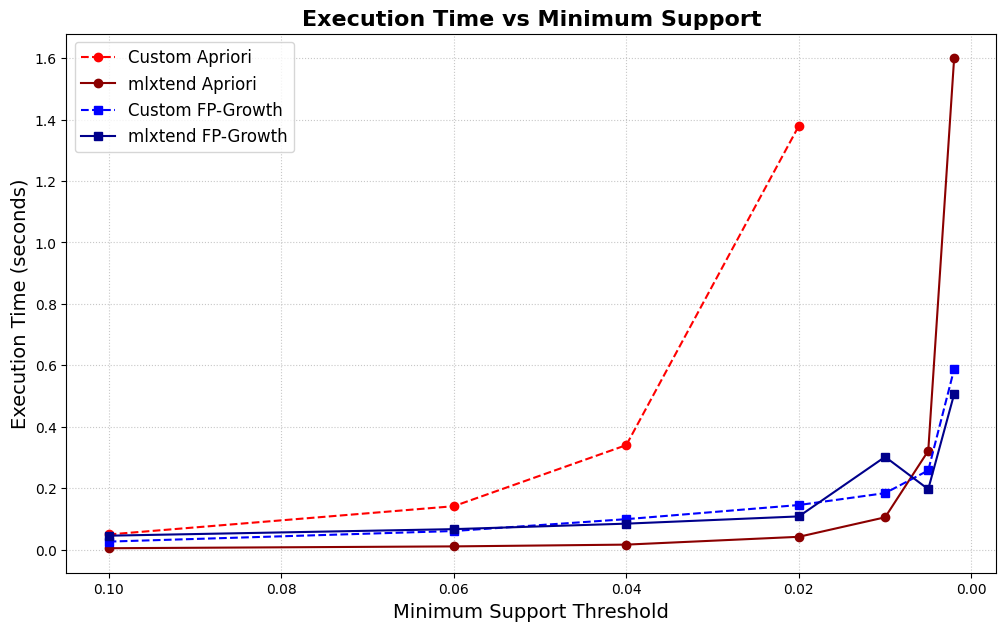

In [ ]:
import matplotlib.pyplot as plt

# Define the range of support values to test
support_values = [0.1, 0.06, 0.04, 0.02, 0.01, 0.005, 0.002]
SKIP_CUSTOM_APRIORI_BELOW = 0.015

# Storage for execution times
times = {
    'Custom Apriori': [],
    'Library Apriori': [],
    'Custom FP-Growth': [],
    'Library FP-Growth': []
}

print("Starting benchmark. This might take a while on low support values...")

for sup in support_values:
    print(f"Testing min_support = {sup}...")
    
    # Custom Apriori
    if sup > SKIP_CUSTOM_APRIORI_BELOW:
        _, _, t_ca = run_custom_pipeline(custom_apriori, transactions, sup, MIN_CONFIDENCE, MIN_LIFT)
        times['Custom Apriori'].append(t_ca)
    else:
        print("Skipping Custom Apriori for this low support to save time/plot scale.")
        times['Custom Apriori'].append(None)
    
    # Library Apriori
    _, _, t_la = run_mlxtend_pipeline(df_ohe, mlx_apriori, sup, MIN_CONFIDENCE, MIN_LIFT)
    times['Library Apriori'].append(t_la)
    
    # Custom FP-Growth
    try:
        _, _, t_cf = run_custom_pipeline(custom_fpgrowth, transactions, sup, MIN_CONFIDENCE, MIN_LIFT)
        times['Custom FP-Growth'].append(t_cf)
    except Exception as e:
        # Fallback in case the simplified stub wasn't fully expanded to return a support dict
        print(f"  [!] Custom FP-Growth failed at sup={sup}. Recording 0. Error: {e}")
        times['Custom FP-Growth'].append(0)
        
    # Library FP-Growth
    _, _, t_lf = run_mlxtend_pipeline(df_ohe, mlx_fpgrowth, sup, MIN_CONFIDENCE, MIN_LIFT)
    times['Library FP-Growth'].append(t_lf)

print("Benchmark finished! Plotting results...")

# Plotting
plt.figure(figsize=(12, 7))

# Plot lines
plt.plot(support_values, times['Custom Apriori'], label='Custom Apriori', marker='o', color='red', linestyle='--')
plt.plot(support_values, times['Library Apriori'], label='mlxtend Apriori', marker='o', color='darkred')

plt.plot(support_values, times['Custom FP-Growth'], label='Custom FP-Growth', marker='s', color='blue', linestyle='--')    
plt.plot(support_values, times['Library FP-Growth'], label='mlxtend FP-Growth', marker='s', color='darkblue')

# Formatting the plot
plt.title('Execution Time vs Minimum Support', fontsize=16, fontweight='bold')
plt.xlabel('Minimum Support Threshold', fontsize=14)
plt.ylabel('Execution Time (seconds)', fontsize=14)

# Invert X-axis because we are decreasing support, which INCREASES complexity
plt.gca().invert_xaxis()

plt.grid(True, linestyle=':', alpha=0.7)
plt.legend(fontsize=12)

# Save and show
plt.savefig('plots/algorithm_benchmark.png', dpi=300, bbox_inches='tight')
plt.show()